<a href="https://colab.research.google.com/github/lia-lubit/DESIxSO/blob/main/CMB_LSS_Project_%E2%80%94_Fiducial_Cosmology_Building.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print('Comment notation:')
print('#: description of what is being done')
print('##: question')
print('###: problem')
print('####: task')

Comment notation:
#: description of what is being done
##: question
###: problem
####: task


In [ ]:
import sys
!{sys.executable} -m pip install pyccl
!{sys.executable} -m pip install camb

In [ ]:
# import necessary tools
import sys
!{sys.executable} -m pip install pyccl
!{sys.executable} -m pip install camb
import astropy
from astropy.cosmology import LambdaCDM, w0waCDM
import astropy.units as units
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib import cm
import numpy as np
import scipy
from scipy.stats import linregress
from IPython.display import display, Math
from scipy.integrate import simpson
from mpl_toolkits.mplot3d import Axes3D
from google.colab import files, drive
import pylab as pyplt
import pyccl as ccl
import camb
from camb import model, initialpower
%matplotlib inline

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# data

# DESI-HSC
HSC_dist_0_3 = np.load("/content/drive/MyDrive/Colab Notebooks/distributions_0.3_3_vF.npz")
print(f"Keys in distributions_0.3_3_vF.npz: {HSC_dist_0_3.files}")

HSC_dist_1_5 = np.load("/content/drive/MyDrive/Colab Notebooks/distributions_1_5_vF.npz")
print(f"Keys in distributions_1_5_vF.npz: {HSC_dist_1_5.files}")

HSC_dist_0_3_a = np.load("/content/drive/MyDrive/Colab Notebooks/distributions_0.3_3_vF.npz")['1/nz_mean']
HSC_dist_0_3_b = np.load("/content/drive/MyDrive/Colab Notebooks/distributions_0.3_3_vF.npz")['2/nz_mean']
HSC_dist_0_3_c = np.load("/content/drive/MyDrive/Colab Notebooks/distributions_0.3_3_vF.npz")['3/nz_mean']
HSC_dist_0_3_d = np.load("/content/drive/MyDrive/Colab Notebooks/distributions_0.3_3_vF.npz")['4/nz_mean']
HSC_dist_0_3_z = np.load("/content/drive/MyDrive/Colab Notebooks/distributions_0.3_3_vF.npz")['z']
HSC_dist_0_3 = np.column_stack((HSC_dist_0_3_z, HSC_dist_0_3_a, HSC_dist_0_3_b, HSC_dist_0_3_c, HSC_dist_0_3_d)) # make into 2D array for easy processing

HSC_dist_1_5_a = np.load("/content/drive/MyDrive/Colab Notebooks/distributions_1_5_vF.npz")['1/nz_mean']
HSC_dist_1_5_b = np.load("/content/drive/MyDrive/Colab Notebooks/distributions_1_5_vF.npz")['2/nz_mean']
HSC_dist_1_5_c = np.load("/content/drive/MyDrive/Colab Notebooks/distributions_1_5_vF.npz")['3/nz_mean']
HSC_dist_1_5_d = np.load("/content/drive/MyDrive/Colab Notebooks/distributions_1_5_vF.npz")['4/nz_mean']
HSC_dist_1_5_z = np.load("/content/drive/MyDrive/Colab Notebooks/distributions_1_5_vF.npz")['z']
HSC_dist_1_5 = np.column_stack((HSC_dist_1_5_z, HSC_dist_1_5_a, HSC_dist_1_5_b, HSC_dist_1_5_c, HSC_dist_1_5_d)) # make into 2D array for easy processing

# DESI Lens Data

DESI_lens_data = np.loadtxt("/content/drive/MyDrive/Colab Notebooks/des_nz_gamma.txt")

DESI_lens_data = DESI_lens_data[7:]  # removes the first 7 values (headers)
DESI_lens_data = DESI_lens_data.reshape(-1, 6) #shape into array with columns z, nz0 -- nz4

# Split into separate arrays
DESI_lens_z    = DESI_lens_data[:, 0]
DESI_lens_nz_a = DESI_lens_data[:, 1]
DESI_lens_nz_b = DESI_lens_data[:, 2]
DESI_lens_nz_c = DESI_lens_data[:, 3]
DESI_lens_nz_d = DESI_lens_data[:, 4]
DESI_lens_nz_e = DESI_lens_data[:, 5]

DESI_lens_data = np.column_stack((DESI_lens_z, DESI_lens_nz_a, DESI_lens_nz_b, DESI_lens_nz_c, DESI_lens_nz_d))

Keys in distributions_0.3_3_vF.npz: ['z', '1/nz_median', '1/nz_mean', '1/nz_lower', '1/nz_upper', '1/nz_median_mu', '1/nz_mean_mu', '1/nz_lower_mu', '1/nz_upper_mu', '2/nz_median', '2/nz_mean', '2/nz_lower', '2/nz_upper', '2/nz_median_mu', '2/nz_mean_mu', '2/nz_lower_mu', '2/nz_upper_mu', '3/nz_median', '3/nz_mean', '3/nz_lower', '3/nz_upper', '3/nz_median_mu', '3/nz_mean_mu', '3/nz_lower_mu', '3/nz_upper_mu', '4/nz_median', '4/nz_mean', '4/nz_lower', '4/nz_upper', '4/nz_median_mu', '4/nz_mean_mu', '4/nz_lower_mu', '4/nz_upper_mu']
Keys in distributions_1_5_vF.npz: ['z', '1/nz_median', '1/nz_mean', '1/nz_lower', '1/nz_upper', '1/nz_median_mu', '1/nz_mean_mu', '1/nz_lower_mu', '1/nz_upper_mu', '2/nz_median', '2/nz_mean', '2/nz_lower', '2/nz_upper', '2/nz_median_mu', '2/nz_mean_mu', '2/nz_lower_mu', '2/nz_upper_mu', '3/nz_median', '3/nz_mean', '3/nz_lower', '3/nz_upper', '3/nz_median_mu', '3/nz_mean_mu', '3/nz_lower_mu', '3/nz_upper_mu', '4/nz_median', '4/nz_mean', '4/nz_lower', '4/nz_up

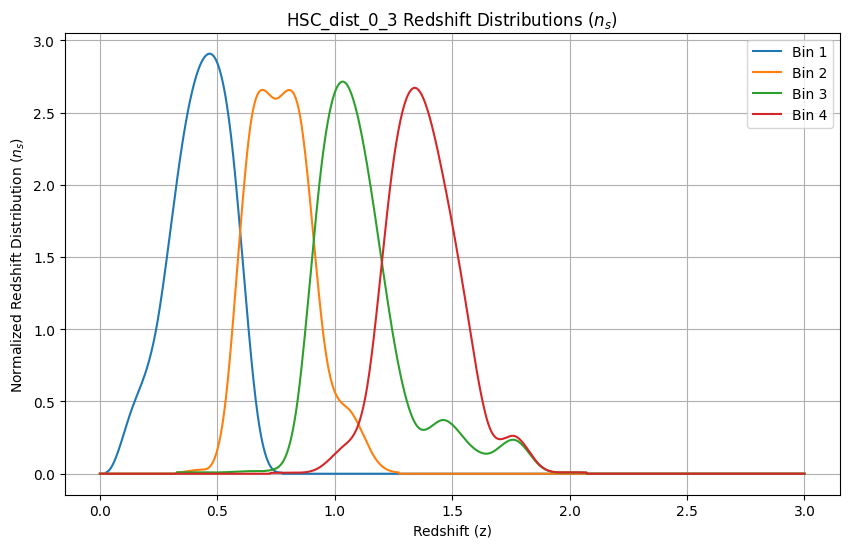

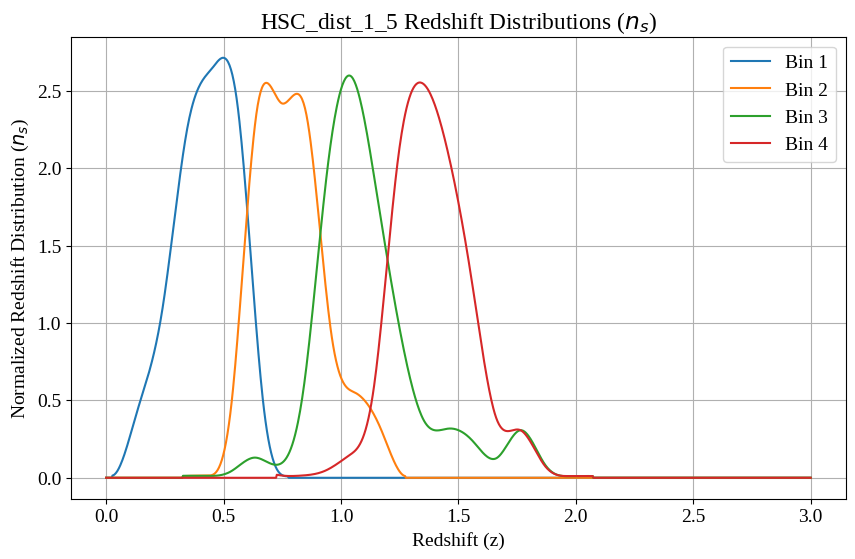

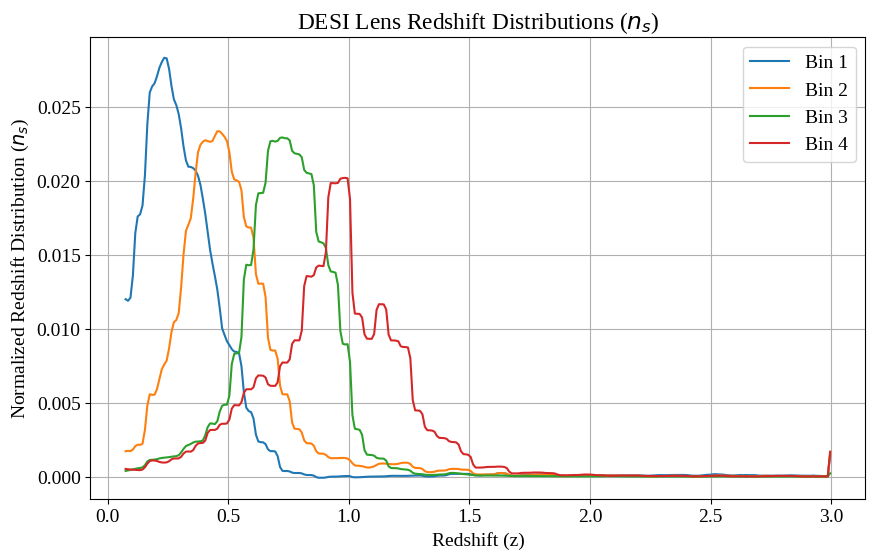

In [ ]:
# graph HSC source distributions

plt.figure(figsize=(10, 6))
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_a, label='Bin 1')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_b, label='Bin 2')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_c, label='Bin 3')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_d, label='Bin 4')
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('HSC_dist_0_3 Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_a, label='Bin 1')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_b, label='Bin 2')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_c, label='Bin 3')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_d, label='Bin 4')
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('HSC_dist_1_5 Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(DESI_lens_z, DESI_lens_nz_a, label='Bin 1')
plt.plot(DESI_lens_z, DESI_lens_nz_b, label='Bin 2')
plt.plot(DESI_lens_z, DESI_lens_nz_c, label='Bin 3')
plt.plot(DESI_lens_z, DESI_lens_nz_d, label='Bin 4')
#plt.plot(DESI_lens_z, DESI_lens_nz_e, label='Bin 5')
#### nz_5 has values all of order e7 or above,
#### while the others have values of order e-5 or below
#### what's going on here?
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('DESI Lens Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14
plt.show()

Mean redshifts for DESI lens bins:
  Lens Bin 1: 0.343
  Lens Bin 2: 0.522
  Lens Bin 3: 0.742
  Lens Bin 4: 0.936


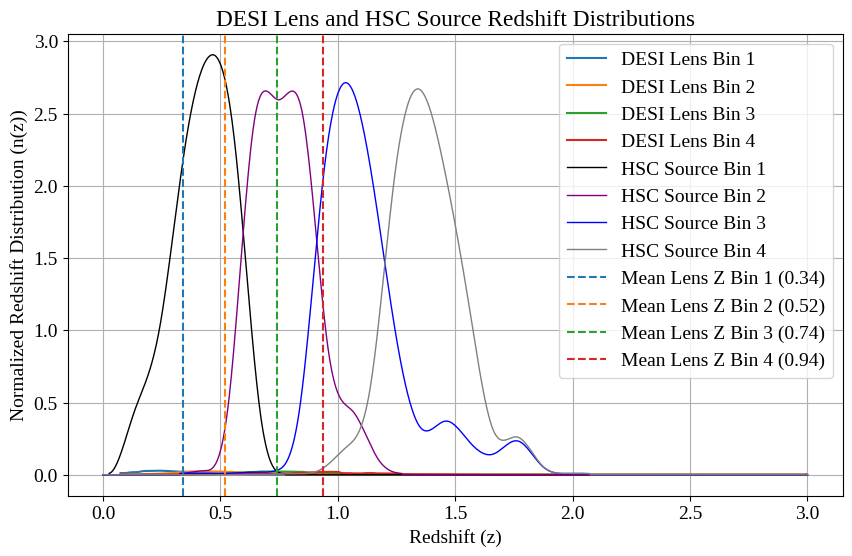

In [ ]:
# calculate mean lens redshifts for each DESI lens bin
mean_desi_lens_redshifts = []

# DESI_lens_data contains z in col 0, then nz_a, nz_b, nz_c, nz_d in cols 1-4
nz_arrays_desi = [DESI_lens_nz_a, DESI_lens_nz_b, DESI_lens_nz_c, DESI_lens_nz_d]
z_lens_grid = DESI_lens_data[:, 0]

for i, n_lens_i in enumerate(nz_arrays_desi):
    if np.sum(n_lens_i) == 0:
        mean_desi_lens_redshifts.append(np.nan)
    else:
        z_l_i = scipy.integrate.trapezoid(z_lens_grid * n_lens_i, z_lens_grid) / scipy.integrate.trapezoid(n_lens_i, z_lens_grid)
        mean_desi_lens_redshifts.append(z_l_i)

print("Mean redshifts for DESI lens bins:")
for i, z_l_i in enumerate(mean_desi_lens_redshifts):
    print(f"  Lens Bin {i+1}: {z_l_i:.3f}")

# plot DESI lens distributions and the first HSC_dist_0_3 source distribution
plt.figure(figsize=(10, 6))
plt.plot(DESI_lens_z, DESI_lens_nz_a, label='DESI Lens Bin 1')
plt.plot(DESI_lens_z, DESI_lens_nz_b, label='DESI Lens Bin 2')
plt.plot(DESI_lens_z, DESI_lens_nz_c, label='DESI Lens Bin 3')
plt.plot(DESI_lens_z, DESI_lens_nz_d, label='DESI Lens Bin 4')

plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_a, label='HSC Source Bin 1', linestyle='-', linewidth=1, color='black')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_b, label='HSC Source Bin 2', linestyle='-', linewidth=1, color='purple')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_c, label='HSC Source Bin 3', linestyle='-', linewidth=1, color='blue')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_d, label='HSC Source Bin 4', linestyle='-', linewidth=1, color='gray')

# Add vertical lines for mean lens redshifts
for i, z_l_i in enumerate(mean_desi_lens_redshifts):
    plt.axvline(x=z_l_i, color=f'C{i}', linestyle='--', label=f'Mean Lens Z Bin {i+1} ({z_l_i:.2f})')

plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution (n(z))')
plt.title('DESI Lens and HSC Source Redshift Distributions')
plt.legend()
plt.grid(True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14
plt.show()

In [ ]:
# CCL
print('CCL cosmology parameters:')
print('Omega_c: the density fraction at z=0 of CDM.')
print('Omega_b: the density fraction at z=0 of baryons.')
print('h: the Hubble constant in units of 100 k⁢m/s/M⁢p⁢c.')
print('Omega_k: the curvature density fraction at 𝑧 =0.')
print('Omega_g: the density of radiation (not including massless neutrinos.')
print('w0: first order term of the dark energy equation of state.')
print('wa: second order term of the dark energy equation of state.')

CCL cosmology parameters:
Omega_c: the density fraction at z=0 of CDM.
Omega_b: the density fraction at z=0 of baryons.
h: the Hubble constant in units of 100 k⁢m/s/M⁢p⁢c.
Omega_k: the curvature density fraction at 𝑧 =0.
Omega_g: the density of radiation (not including massless neutrinos.
w0: first order term of the dark energy equation of state.
wa: second order term of the dark energy equation of state.


In [ ]:
# CCL cosmolgoies

# сosmology -- standard CCL + DESI waw0
h = 0.6674
w0 = -0.752
wa = -0.86
Om0 = 0.3191
Omega_c = 0.27
Omega_b = 0.045
sigma8 = 0.8
n_s = 0.96
w0wa_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, h=h, sigma8=sigma8,
                               n_s=n_s, w0=w0, wa=wa, transfer_function='bbks')

# сosmology -- standard CCL + DESI curved h and Omega_k
h = 0.6850
Om0 = 0.3191
Omega_c = 0.27
Omega_b = 0.045
sigma8 = 0.8
n_s = 0.96
Omega_k = 2.3e-3
curved_LCDM_cosmology = ccl.Cosmology(Omega_k = Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, sigma8=sigma8,
                               n_s=n_s, transfer_function='bbks')

# cosmology -- standard CCL + flat LCDM
z_star = 1100.0
Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
Ode0 = 1 - Om0 # dark energy density
Omega_k = 0
Omega_b = 0.045
Omega_c = 0.27
flat_LCDM_cosmology = ccl.Cosmology(Omega_k = Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, sigma8=sigma8,
                               n_s=n_s, transfer_function='bbks')

In [ ]:
def calculate_and_plot_Cls(
    cosmology,        # ccl.Cosmology object
    source_data,         # 2D array: z, n_z_bin1, n_z_bin2, ...
    lens_data,          # 2D array: z, n_z_bin1, n_z_bin2, ...
    correlation_types=['LL', 'SS', 'SL', 'CL'] # List of correlation types to plot
):

    # extract lens and source redshift grids and distributions
    z_lens_grid = lens_data[:, 0]
    n_lens_dists = [lens_data[:, i] for i in range(1, lens_data.shape[1])]
    num_lens_bins = len(n_lens_dists)
    z_source_grid = source_data[:, 0]
    n_source_dists = [source_data[:, i] for i in range(1, source_data.shape[1])]
    num_source_bins = len(n_source_dists)
    z_CMB = 1090

    # initialize ccl.NumberCountsTracer for each lens and source bin
    lens_tracers_nc = []
    source_tracers_nc = []
    for i, n_z_lens_bin in enumerate(n_lens_dists):
        # use a constant linear bias of 1
        bias_values = np.ones_like(z_lens_grid)
        tracer = ccl.NumberCountsTracer(cosmology, has_rsd=False,
                                        dndz=(z_lens_grid, n_z_lens_bin),
                                        bias=(z_lens_grid, bias_values))
        lens_tracers_nc.append(tracer)
    for i, n_z_source_bin in enumerate(n_source_dists):
            # use a constant linear bias of 1
            bias_values = np.ones_like(z_source_grid)
            tracer = ccl.NumberCountsTracer(cosmology, has_rsd=False,
                                            dndz=(z_source_grid, n_z_source_bin),
                                            bias=(z_source_grid, bias_values))
            source_tracers_nc.append(tracer)

    # create CMB lensing tracerrs
    CMB_tracer = ccl.CMBLensingTracer(cosmology, z_source=z_CMB)

    # define common range of multipoles and a dictionary
    ell_values = np.logspace(np.log10(2), np.log10(3000), 100)
    cl_spectra = {}

    # generate a colormap for distinct colors
    colors = cm.get_cmap('tab20', num_lens_bins ** 2)
    color_idx = 0

    # Lens-Lens auto-corr spectra
    if 'LL' in correlation_types:
        for i in range(num_lens_bins):
            for k in range(i, num_lens_bins): # Avoid duplicates, i.e., LL_1_2 is same as LL_2_1
                cl = cosmology.angular_cl(lens_tracers_nc[i], lens_tracers_nc[k], ell_values)
                cl_spectra[f'LL{i+1}_{k+1}'] = cl


    # Source-source auto-corr spectra
    if 'SS' in correlation_types:
        for i in range(num_source_bins):
            for k in range(i, num_source_bins): # Avoid duplicates, i.e., LL_1_2 is same as LL_2_1
                cl = cosmology.angular_cl(source_tracers_nc[i], source_tracers_nc[k], ell_values)
                cl_spectra[f'SS{i+1}_{k+1}'] = cl


    # Lens-Source cross-corr spectra
    if 'SL' in correlation_types:
        for i in range (num_source_bins):
            for k in range(num_lens_bins):
                cl = cosmology.angular_cl(lens_tracers_nc[k], source_tracers_nc[i], ell_values)
                cl_spectra[f'SL{i+1}_{k+1}'] = cl

    # CMB-lens cross-corr spectra
    if 'CL' in correlation_types:
        for j in range(num_lens_bins):
            cl = cosmology.angular_cl(lens_tracers_nc[j], CMB_tracer, ell_values)
            cl_spectra[f'CL{j+1}'] = cl

    # plot all calculated Cl spectra
    plt.figure(figsize=(12, 8))
    for key, cl_values in cl_spectra.items():
        plt.loglog(ell_values, cl_values, label=key, color=colors(color_idx % colors.N))
        color_idx += 1

    plt.xlabel(r'Multipole, $\ell$')
    plt.ylabel(r'Angular Power Spectrum, $C_\ell$')
    plt.title(r'Angular Power Spectra ($C_\ell$) for ' + ', '.join(correlation_types) + ' Correlations')
    plt.legend(loc='best', fontsize='small', bbox_to_anchor=(1.05, 1))
    plt.grid(True, which="both", ls="-")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_100856/1345685348.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', num_lens_bins ** 2)


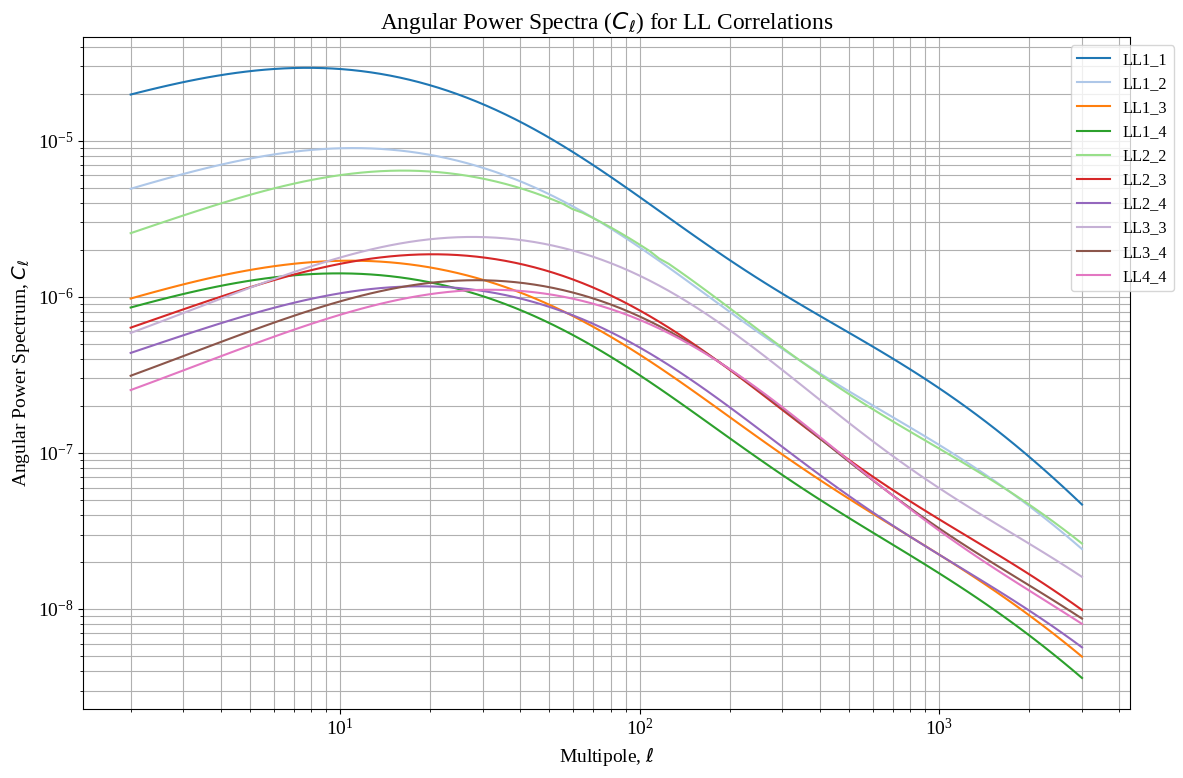

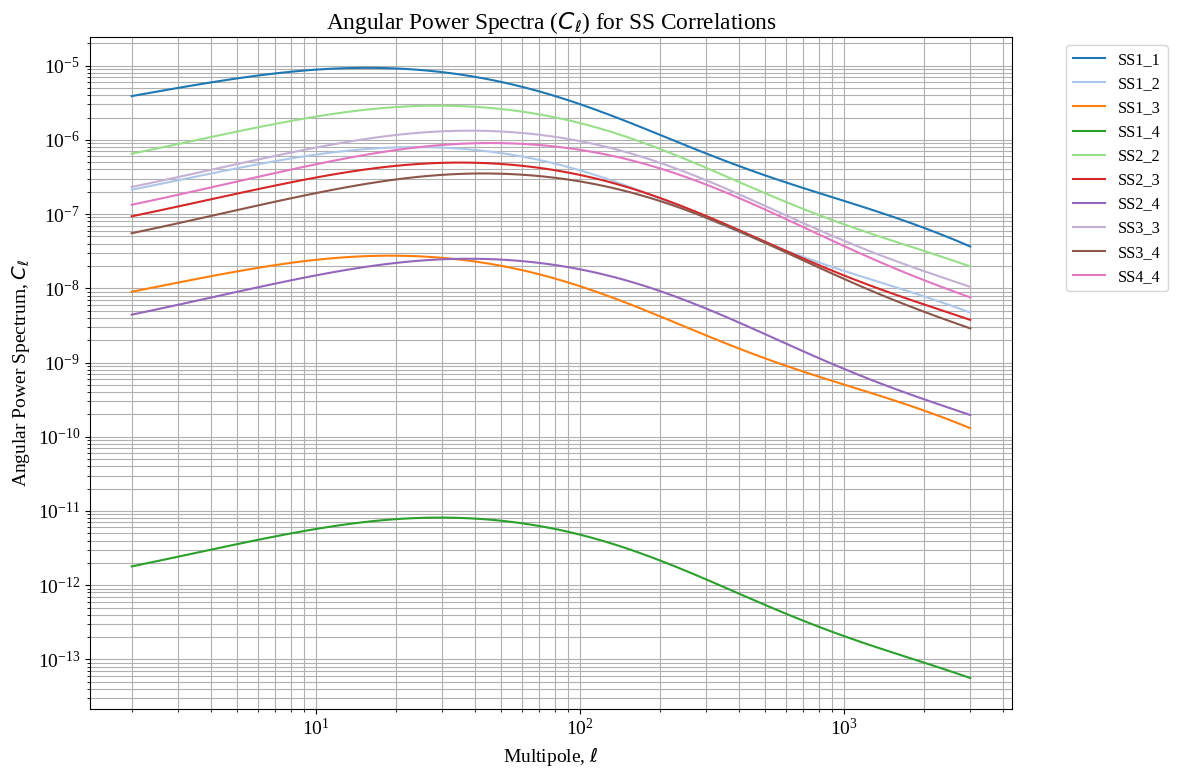

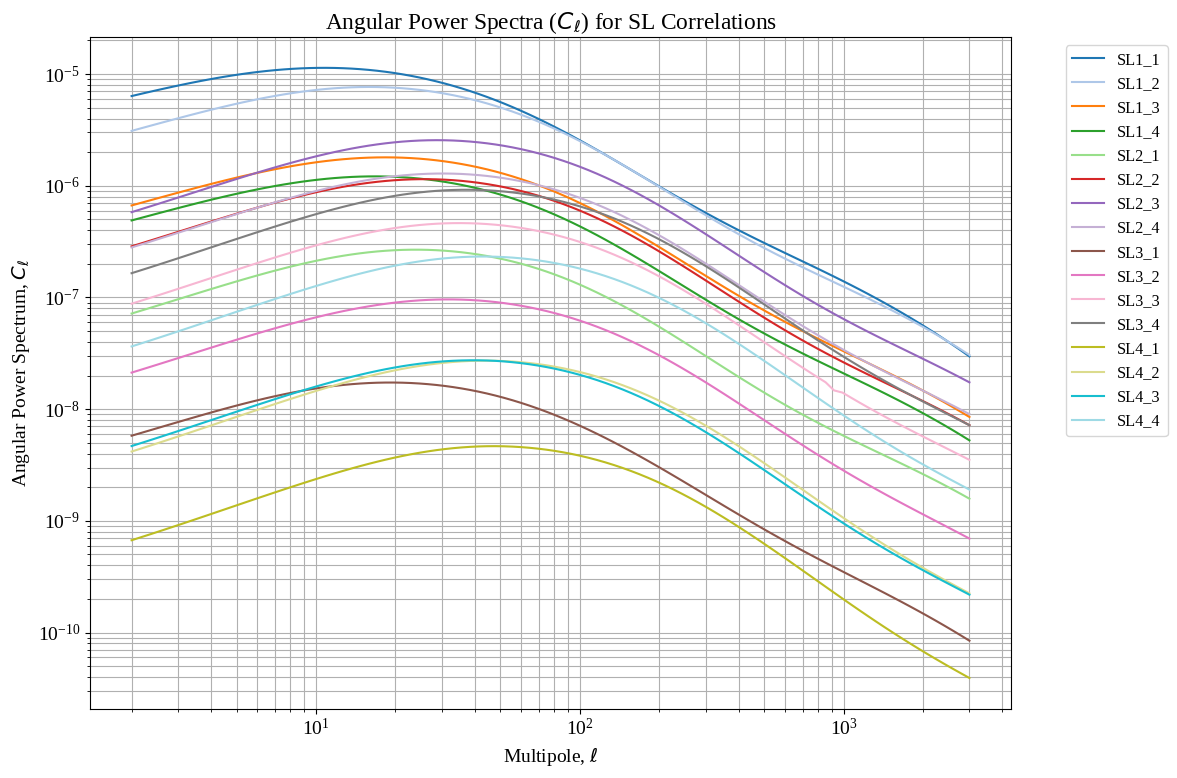

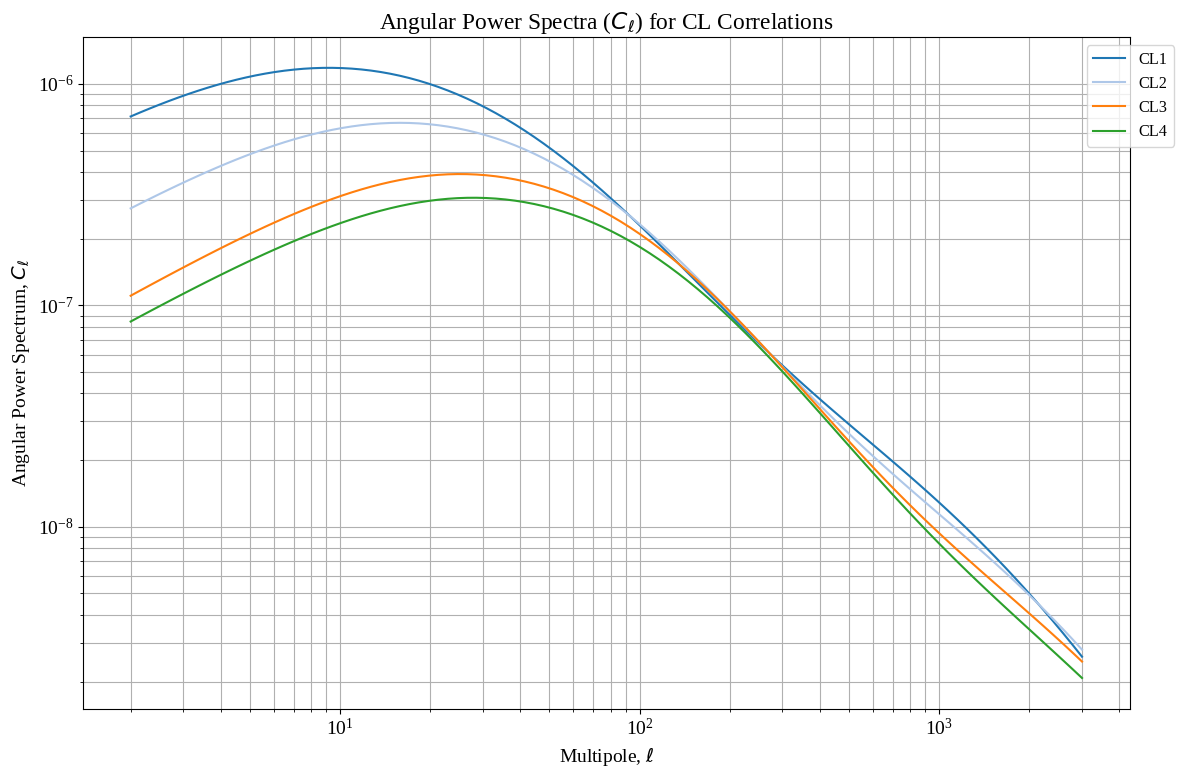

In [ ]:
calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['LL']
)

calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['SS']
)

calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['SL']
)

calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CL']
)

The covariance matrix is rather complicated because we have many different types of data for which we need to consider the covariances. We'll set up the data vector:

$$\mathbf{D} = [C_\ell^{\phi\phi}, C_\ell^{gg}, C_\ell^{\gamma\gamma}, C_\ell^{g\gamma}, C_\ell^{g\phi}, C_\ell^{\gamma\phi}]$$

This vector consists of:
* **CMB lensing auto-spectrum:** $C_\ell^{\phi\phi}$
* **Lens galaxy auto/cross-spectrum:** $C_\ell^{gg}$ (galaxy clustering)
* **Source galaxy auto/cross-spectrum:** $C_\ell^{\gamma\gamma}$ (cosmic shear)
* **Lens-source cross-spectrum:** $C_\ell^{g\gamma}$ (galaxy-galaxy lensing)
* **Galaxy lensing–CMB lensing cross-spectrum:** $C_\ell^{g\phi}$
* **Source shear–CMB lensing cross-spectrum:** $C_\ell^{\gamma\phi}$

If we have **a** lens bins and **b** source bins we have 1 CMB, $\frac{a(a+1)}{2}$ lens-lens, $\frac{b(b+1)}{2}$ source-source, ab lens-source, a lens-CMB, and b source-CMB spectra. Each component is a list with $N_l$ entries.

The covariance matrix includes the covariances of all spectra with all other spectra. This means that it is a massive block matrix, with each block being an $N_\ell \times N_\ell$ matrix.

$$\text{Cov}_{\text{master }}[i,j] = \text{Cov}(D_i, D_j)$$
$$\mathrm{Cov}(C^{ab}_{\ell}, C^{cd}_{\ell'}) = \frac{\delta_{\ell \ell'}}{(2\ell + 1)\, f_{\mathrm{sky}}} \left( C^{ac}_\ell C^{bd}_\ell + C^{ad}_\ell C^{bc}_\ell \right)$$

In order to do a proper MCMC, we will need to calculate the entries in the master covariance matrix and input it into Cobaya.

Note that calculating covariances will be a little tricky because we'll need the computer to figure out what spectra are being considered, separate out their variables, swap them around, and then locate the correct spectra for the product terms.

In [ ]:
# we've got a big matrix with a lot of subparts,
# so we need to organize this and make it easy to search through
# this will make a class of a map that has functions within it that generate pairs of spectra
# and find the indices that define the submatrices corresponding to the covariances between spectra

class ForecastMap:
    def __init__(self, n_lens=4, n_src=4, n_ell=20):
        self.n_lens = n_lens
        self.n_src = n_src
        self.n_ell = n_ell

        # list of unique spectra
        self.pairs = self._generate_pairs()
        self.pair_to_index = {p: i for i, p in enumerate(self.pairs)}

        # length of data vector
        self.vector_length = len(self.pairs) * n_ell

    def _generate_pairs(self):
        p = []

        # CMB spectra
        p += [('phi','phi')]

        # Lens auto/cross -- not zero indexing because of convention
        for i in range(1, self.n_lens + 1):
            for j in range(i, self.n_lens + 1):
                p.append((f'g{i}', f'g{j}'))

        # Source auto/cross
        for i in range(1, self.n_src + 1):
            for j in range(i, self.n_src + 1):
                p.append((f's{i}', f's{j}'))

        # Lens-source cross
        for i in range(1, self.n_lens + 1):
            for j in range(1, self.n_src + 1):
                p.append((f'g{i}', f's{j}'))

        # Lensing cross
        for i in range(1, self.n_lens + 1):
            p.append((f'g{i}', 'phi'))
        for j in range(1, self.n_src + 1):
            p.append((f's{j}', 'phi'))

        return p

    # this lets you find the indices of the start and end of the section with the given covariance
    def get_indices(self, pair_label):
        # ensure ordering is consistent
        if pair_label in self.pair_to_index:
            idx = self.pair_to_index[pair_label]
        elif (pair_label[1], pair_label[0]) in self.pair_to_index:
            idx = self.pair_to_index[(pair_label[1], pair_label[0])]
        else:
            raise ValueError(f"Pair {pair_label} not found.")
        start = idx * self.n_ell
        end = (idx + 1) * self.n_ell #### why?
        return start, end

In [ ]:
# compute general spectra with noise

def build_tracers_from_data(cosmo, lens_data, source_data):
    # build CCL tracers from distributions
    z_lens = lens_data[:, 0]
    z_source = source_data[:, 0]

    n_lens = lens_data.shape[1] - 1
    n_src = source_data.shape[1] - 1

    lens_tracers = []
    for i in range(1, n_lens + 1):
        nz = lens_data[:, i]
        bias = np.ones_like(z_lens)
        tracer = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(z_lens, nz), bias=(z_lens, bias))
        lens_tracers.append(tracer)

    source_tracers = []
    for i in range(1, n_src + 1):
        nz = source_data[:, i]
        tracer = ccl.WeakLensingTracer(cosmo, dndz=(z_source, nz))
        source_tracers.append(tracer)

    cmb_tracer = ccl.CMBLensingTracer(cosmo, z_source=1090)

    return lens_tracers, source_tracers, cmb_tracer

# build tracer dictionary
def build_tracer_dict(lens_tracers, source_tracers, cmb_tracer):
    tracer_dict = {'phi': cmb_tracer}

    for i, tr in enumerate(lens_tracers):
        tracer_dict[f'g{i+1}'] = tr
    for i, tr in enumerate(source_tracers):
        tracer_dict[f's{i+1}'] = tr

    return tracer_dict

# build noise dictionary
#### check this
def build_noise_dict(f_map, ells, shot_noise_lens=None, shape_noise_source=None, cmb_noise_phi=None):
    noise_dict = {}

    if shot_noise_lens is not None:
        # Assuming shot_noise_lens is a list/array with noise for each lens bin
        for i in range(1, len(shot_noise_lens) + 1):
            noise_dict[(f'g{i}', f'g{i}')] = np.ones_like(ells) / shot_noise_lens[i-1]

    if shape_noise_source is not None:
        # Assuming shape_noise_source is a list/array with noise for each source bin
        for i in range(1, len(shape_noise_source) + 1):
            noise_dict[(f's{i}', f's{i}')] = np.ones_like(ells) * shape_noise_source[i-1]

    if cmb_noise_phi is not None:
        noise_dict[('phi','phi')] = cmb_noise_phi

    return noise_dict

# build spectra dictionary
def build_spectra_dict(cosmo, f_map, tracer_dict, ells, noise_dict=None):
    spectra_dict = {}

    # Iterate through all unique pairs of tracers in tracer_dict to calculate Cls
    tracer_labels = list(tracer_dict.keys())
    for i, label1 in enumerate(tracer_labels):
        for j, label2 in enumerate(tracer_labels):
            # ensure consistent key ordering (e.g., ('g1', 's1') not ('s1', 'g1'))
            # only calculate each unique pair once
            key_fwd = (label1, label2)
            key_bwd = (label2, label1)

            if key_fwd in spectra_dict or key_bwd in spectra_dict: # spectra already handled
                continue
            else:
                tracer1 = tracer_dict[label1]
                tracer2 = tracer_dict[label2]
                Cl = ccl.angular_cl(cosmo, tracer1, tracer2, ells)

            # store with canonical ordering
            if label1 < label2: # Simple lexicographical order for consistency
                spectra_dict[(label1, label2)] = Cl
            else:
                spectra_dict[(label2, label1)] = Cl # Store with smaller label first

    # add noise terms
    if noise_dict is not None:
        for key_noise, noise_val in noise_dict.items():
            # only add noise to auto-spectra.
            if key_noise[0] == key_noise[1]:
                spectra_dict[key_noise] += noise_val

    return spectra_dict

In [ ]:
import numpy as np
# build covariance matrix
# this is a class that is a massive covariance matrix
# with functions that has functions

class CovarianceMatrix:
    # initialize
    def __init__(self, f_map, spectra_dict, f_sky):
        self.f_map = f_map # ForecastMap object
        self.spectra_dict = spectra_dict #dictionary mapping (tracer1, tracer2) to C_l^(tracer1, tracer2) array of length n_ell
        self.f_sky = f_sky
        self.N = f_map.vector_length

        # master covariance
        self.matrix = np.zeros((self.N, self.N))
        self.block_slices = {}

        # build covariance
        self._build_master_covariance()

    # get the relevant C_l spectra
    def _compute_block(self, pair_A, pair_B):
        N_ell = self.f_map.n_ell
        a, b = pair_A
        c, d = pair_B

        def get_Cl(x, y):
            key_fwd = (x,y)
            key_bwd = (y,x)
            if key_fwd in self.spectra_dict:
                return self.spectra_dict[key_fwd]
            elif key_bwd in self.spectra_dict:
                return self.spectra_dict[key_bwd]
            else:
                # If the cross-spectrum is not explicitly calculated, assume it's zero.
                # This handles terms like Cl^(g, T) which are not part of f_map.pairs
                return np.zeros(self.f_map.n_ell) # Return an array of zeros

        Cl_ac = get_Cl(a, c)
        Cl_bd = get_Cl(b, d)
        Cl_ad = get_Cl(a, d)
        Cl_bc = get_Cl(b, c)

        block = np.zeros((N_ell, N_ell))

        # input values on the diagonals, all others are zero (Gaussian)
        for i in range(N_ell):
            block[i,i] = (Cl_ac[i]*Cl_bd[i] + Cl_ad[i]*Cl_bc[i]) / ((2*i + 1) * self.f_sky)
        return block

    def _build_master_covariance(self):
        for pair_A in self.f_map.pairs:
            sA, eA = self.f_map.get_indices(pair_A) #sA is start index for A, eA is end index for A
            for pair_B in self.f_map.pairs:
                sB, eB = self.f_map.get_indices(pair_B)
                # compute entries
                block = self._compute_block(pair_A, pair_B)
                # input entries into master matrix
                self.matrix[sA:eA, sB:eB] = block
                # create calling path
                self.block_slices[(pair_A, pair_B)] = (slice(sA, eA), slice(sB, eB))

    # access
    def get_block(self, pair_A, pair_B):
        # return the N_ell x N_ell block for these two spectra
        sA, sB = self.block_slices[(pair_A, pair_B)]
        return self.matrix[sA, sB]

    def get_value(self, pair_A, pair_B, ell_idx):
        # return covariance value for two spectra and a specific l
        sA, sB = self.block_slices[(pair_A, pair_B)]
        return self.matrix[sA.start + ell_idx, sB.start + ell_idx]

In [ ]:
import numpy as np

def build_full_covariance_from_data(
    cosmo,
    lens_data,
    source_data,
    f_sky,
    n_ell=3000,
    shot_noise_lens=None,
    shape_noise_source=None
):

    # build ForecastMap
    f_map = ForecastMap(n_lens=lens_data.shape[1]-1, n_src=source_data.shape[1]-1, n_ell=n_ell)
    ells = np.arange(2, n_ell+2)

    # build spectra
    lens_tracers, source_tracers, cmb_tracer = build_tracers_from_data(cosmo, lens_data, source_data)
    tracer_dict = build_tracer_dict(lens_tracers, source_tracers, cmb_tracer)
    noise_dict = build_noise_dict(f_map, ells, shot_noise_lens, shape_noise_source, cmb_noise_phi)
    spectra_dict = build_spectra_dict(cosmo, f_map, tracer_dict, ells, noise_dict)

    # build covariance -- it is an instance of the CovarianceMatrix class object
    # we can call functions on it
    cov = CovarianceMatrix(f_map, spectra_dict, f_sky)

    return cov, spectra_dict, f_map

In [ ]:
# store and plot a specific subset of the covariance matrix
#### check this

def plot_subset_covariance_matrix(
    cosmo,
    lens_data,
    source_data,
    f_sky,
    desired_spectra, # e.g., [('g1', 'g1'), ('g1', 's1')]
    n_ell=3000,
    shot_noise_lens=None,
    shape_noise_source=None,
    title='Subset of Gaussian Covariance Matrix'
):
    # build the full covariance matrix
    cov_obj, spectra_dict, f_map = build_full_covariance_from_data(
        cosmo=cosmo,
        lens_data=lens_data,
        source_data=source_data,
        f_sky=f_sky,
        n_ell=n_ell,
        shot_noise_lens=shot_noise_lens,
        shape_noise_source=shape_noise_source
    )

    # determine dimensions for the subset matrix
    num_desired = len(desired_spectra)
    total_dim = num_desired * n_ell
    subset_matrix = np.zeros((total_dim, total_dim))

    # populate the subset matrix
    for i in range(num_desired):
        pair_A = desired_spectra[i]
        for j in range(num_desired):
            pair_B = desired_spectra[j]
            # get the N_ell x N_ell block
            block = cov_obj.get_block(pair_A, pair_B)
            # place it into the subset_matrix
            subset_matrix[i * n_ell : (i + 1) * n_ell,
                          j * n_ell : (j + 1) * n_ell] = block

    # plotting
    plt.figure(figsize=(12, 10))
    im = plt.imshow(subset_matrix, cmap='viridis', origin='lower',
                    extent=[0, total_dim, 0, total_dim], # extent for proper aspect ratio/labels
                    norm=LogNorm() # use LogNorm for better visualization of potentially wide range of values
                    )

    # create tick positions and labels for blocks
    tick_positions = []
    tick_labels = []
    for k in range(num_desired):
        tick_positions.append(k * n_ell + n_ell / 2)
        label_a, label_b = desired_spectra[k]
        # format labels nicely, handling CMB specific ones and numerical ones
        if label_a in ['T', 'E'] and label_b in ['T', 'E']:
             tick_labels.append(f'$C^{{{label_a}{label_b}}}$')
        elif label_a == 'phi' and label_b == 'phi':
             tick_labels.append(f'$C^{{\phi\phi}}$')
        elif label_a.startswith('g') and label_b.startswith('g'):
             # Replace 'gX' with 'g_X' for LaTeX subscript
             sa = label_a.replace('g', 'g_')
             sb = label_b.replace('g', 'g_')
             tick_labels.append(f'$C^{{{sa}{sb}}}$')
        elif label_a.startswith('s') and label_b.startswith('s'):
             sa = label_a.replace('s', 's_')
             sb = label_b.replace('s', 's_')
             tick_labels.append(f'$C^{{{sa}{sb}}}$')
        elif (label_a.startswith('g') or label_a.startswith('s')) and label_b == 'phi':
             sa = label_a.replace('g', 'g_').replace('s', 's_')
             tick_labels.append(f'$C^{{{sa}\phi}}$')
        elif (label_b.startswith('g') or label_b.startswith('s')) and label_a == 'phi':
             sb = label_b.replace('g', 'g_').replace('s', 's_')
             tick_labels.append(f'$C^{{\phi{sb}}}$')
        else: # lens-source, or general case
             sa = label_a.replace('g', 'g_').replace('s', 's_')
             sb = label_b.replace('g', 'g_').replace('s', 's_')
             tick_labels.append(f'$C^{{{sa}{sb}}}$')

    plt.xticks(tick_positions, tick_labels, rotation=45, ha='right', fontsize=10)
    plt.yticks(tick_positions, tick_labels, fontsize=10)
    plt.xlabel('Covariance component')
    plt.ylabel('Covariance component')
    plt.title(title)
    plt.colorbar(im, label='Covariance Value (Log Scale)')
    plt.grid(False) # imshow usually doesn't need grid lines over the image itself

    # add lines to delineate the blocks
    for k in range(1, num_desired):
        plt.axvline(k * n_ell, color='white', linestyle='--', linewidth=1)
        plt.axhline(k * n_ell, color='white', linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.show()

    return subset_matrix

<>:59: SyntaxWarning: invalid escape sequence '\p'
<>:71: SyntaxWarning: invalid escape sequence '\p'
<>:74: SyntaxWarning: invalid escape sequence '\p'
<>:59: SyntaxWarning: invalid escape sequence '\p'
<>:71: SyntaxWarning: invalid escape sequence '\p'
<>:74: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_100856/2484348013.py:59: SyntaxWarning: invalid escape sequence '\p'
  tick_labels.append(f'$C^{{\phi\phi}}$')
/tmp/ipykernel_100856/2484348013.py:71: SyntaxWarning: invalid escape sequence '\p'
  tick_labels.append(f'$C^{{{sa}\phi}}$')
/tmp/ipykernel_100856/2484348013.py:74: SyntaxWarning: invalid escape sequence '\p'
  tick_labels.append(f'$C^{{\phi{sb}}}$')


In [ ]:
# example

plot_subset_covariance_matrix(
    flat_LCDM_cosmology,
    DESI_lens_data,
    HSC_dist_0_3,
    f_sky = 0.4,
    desired_spectra = [('g1', 'g1'), ('g1', 's1')],
    n_ell=3000,
    shot_noise_lens=None,
    shape_noise_source=None,
    title='Subset of Gaussian Covariance Matrix'
)

Calculated Cl_TT shape: (3000,)
Calculated Cl_EE shape: (3000,)
Calculated Cl_TE shape: (3000,)
Calculated Cl_phi_phi shape: (3000,)
Number of ell values (target): (3000,)


In [ ]:
# Old stuff

In [ ]:
latex = r"""
\mathrm{Cov} =
\begin{array}{c|c|c}
 & C_{\ell'}^{gg} & C_{\ell'}^{kg} \\
\hline
C_{\ell}^{gg} &
\mathrm{Cov}(C_{\ell}^{gg},C_{\ell'}^{gg}) &
\mathrm{Cov}(C_{\ell}^{gg},C_{\ell'}^{kg}) \\
\hline
C_{\ell}^{kg} &
\mathrm{Cov}(C_{\ell}^{kg},C_{\ell'}^{gg}) &
\mathrm{Cov}(C_{\ell}^{kg},C_{\ell'}^{kg})
\end{array}
"""

display(Math(latex))

In [ ]:
# building gaussian covariance for lens galaxies and CMB data using 1 bin at a time
def plot_diagonal_gaussian_covariance(cosmology, source_data, lens_data, fsky, bin):

    # extract redshift grids
    z_lens = lens_data[:,0]
    z_source = source_data[:,0]

    # build tracers
    nz_lens = lens_data[:,bin]
    bias_lens = np.ones_like(z_lens)
    nz_source = source_data[:,bin]
    bias_source = np.ones_like(z_source)

    source_tracer = ccl.NumberCountsTracer(cosmology, has_rsd=False, dndz=(z_source, nz_source),
                                    bias=(z_source, bias_source))
    lens_tracer = ccl.NumberCountsTracer(cosmology, has_rsd=False, dndz=(z_lens, nz_source),
                                    bias=(z_lens, bias_lens))
    CMB_tracer = ccl.CMBLensingTracer(cosmology, z_source=1090)

    # find out noise contribution
    sigma = 0.26
    n = 30 ####lowkey how many galaxies are there
    fraction = sum(nz) / 3.8824690707889054 # (sum of all n(z) for all bins is 3.88)
    n_gal = n * fraction

    # multipoles
    ell_values = np.arange(2, 3001, 10) # Changed to linear spacing from 2 to 3000 with step 10
    n_ell = len(ell_values)

    # calculate covariance matrix values
    Cov_gg_l_gg_l_prime = np.full((n_ell, n_ell), np.nan)
    Cov_gg_l_kg_l_prime = np.full((n_ell, n_ell), np.nan)
    Cov_kg_l_gg_l_prime = np.full((n_ell, n_ell), np.nan)
    Cov_kg_l_kg_l_prime = np.full((n_ell, n_ell), np.nan)

    #### how do I incorporate noise?
    #### is the noise only for Cl_gg?
    #### what are the off diagonal terms?
    for i in range(n_ell):
        prefactor = 1 / (fsky * (2 * ell_values[i] + 1))
        Cl_gg = cosmology.angular_cl(lens_tracer, lens_tracer, ell_values[i]) + (sigma ** 2 / n_gal)
        Cl_kg = cosmology.angular_cl(lens_tracer, CMB_tracer, ell_values[i])
        Cl_kk = cosmology.angular_cl(CMB_tracer, CMB_tracer, ell_values[i])

        Cov_gg_l_gg_l_prime[i,i] = prefactor * 2 * (Cl_gg ** 2)
        Cov_gg_l_kg_l_prime[i,i] = prefactor * 2 * Cl_gg * Cl_kg
        Cov_kg_l_gg_l_prime[i,i] = prefactor * 2 * Cl_gg * Cl_kg
        Cov_kg_l_kg_l_prime[i,i] = prefactor * ((Cl_kg ** 2) + Cl_gg * Cl_kk)

    # bring matrices together in a big block
    Cov = np.block([
       [Cov_gg_l_gg_l_prime, Cov_gg_l_kg_l_prime],
       [Cov_kg_l_gg_l_prime, Cov_kg_l_kg_l_prime]
    ])

    # plot
    N = Cov.shape[0] // 2  # halfway point
    fig, ax = plt.subplots(figsize=(10, 8)) # Use fig, ax for better control
    im = ax.imshow(Cov)
    ax.axvline(N-0.5, color='black', linewidth=2)
    ax.axhline(N-0.5, color='black', linewidth=2)
    desired_ell_grid_values = np.arange(500, ell_values.max() + 1, 500)

    # gridlines every 500 l
    grid_indices = []
    for target_ell in desired_ell_grid_values:
        if target_ell >= ell_values.min() and target_ell <= ell_values.max():
            # Find the index in ell_values closest to target_ell
            idx = np.argmin(np.abs(ell_values - target_ell))
            grid_indices.append(idx)
    for pos_idx in grid_indices:
        # vertical gridlines
        ax.axvline(pos_idx, color='lightgray', linestyle='--', linewidth=0.8)
        ax.axvline(pos_idx + N, color='lightgray', linestyle='--', linewidth=0.8)
        # horizontal gridlines
        ax.axhline(pos_idx, color='lightgray', linestyle='--', linewidth=0.8)
        ax.axhline(pos_idx + N, color='lightgray', linestyle='--', linewidth=0.8)

    # label
    ax.set_xticks([N/2, N + N/2])
    ax.set_xticklabels([r'$C_{\ell\prime}^{gg}$', r'$C_{\ell\prime}^{kg}$'], fontsize=14)
    ax.set_yticks([N/2, N + N/2])
    ax.set_yticklabels([r'$C_{\ell}^{gg}$', r'$C_{\ell}^{kg}$'], fontsize=14)
    ax.tick_params(axis='x', length=0, labelbottom=True, top=False)
    ax.tick_params(axis='y', length=0, labelleft=True, right=False)

    # show
    fig.colorbar(im, ax=ax)
    ax.set_title(f"Block Covariance Matrix for Bin {bin}", fontsize=16)
    plt.tight_layout()
    plt.show()

In [ ]:
plot_diagonal_gaussian_covariance(flat_LCDM_cosmology, HSC_dist_0_3, DESI_lens_data, fsky=0.4, bin=1)
plot_diagonal_gaussian_covariance(flat_LCDM_cosmology, HSC_dist_0_3, DESI_lens_data, fsky=0.4, bin=2)
plot_diagonal_gaussian_covariance(flat_LCDM_cosmology, HSC_dist_0_3, DESI_lens_data, fsky=0.4, bin=3)
plot_diagonal_gaussian_covariance(flat_LCDM_cosmology, HSC_dist_0_3, DESI_lens_data, fsky=0.4, bin=4)

In [ ]:
# compare old and new methods
print('Old')
plot_diagonal_gaussian_covariance(flat_LCDM_cosmology, HSC_dist_0_3, DESI_lens_data, fsky=0.4, bin=1)

print('New')
plot_subset_covariance_matrix(
    flat_LCDM_cosmology,
    DESI_lens_data,
    HSC_dist_0_3,
    f_sky = 0.4,
    desired_spectra = [('g1', 'g1'), ('g1', 'phi')]
    n_ell=3000,
    shot_noise_lens=None,
    shape_noise_source=None,
    title='Subset of Gaussian Covariance Matrix'
):

In [ ]:
#### To Do
# check that all the code is correct
# transfer to VS code so I can run it properly
# figure out how long things are taking
# run for a few examples and check that it matches the simpler code I already understand

# find noise from partial sky (aside from just the f_sky thing -- does this involve masks?)
# figure out how to plot non diagonals
# derive covariance matrix formulas